# ML Course Homework: Gender Prediction from Transactions

## Task Overview

The goal of this homework is to **predict customer gender** based on their transaction history.  
You will need to **aggregate transaction data into features**, train various machine learning models, and evaluate their performance.  


- **Baseline Goal:** Achieve at least **0.86 ROC-AUC** on the test set.  
---

## 📊 Dataset Details  

The dataset contains **3,751,083 transaction records** for **8,400 customers**.  
It is split into **70% train, 10% validation, and 20% test** by `customer_id`.  

| Column          | Type             | Description |
|-----------------|-----------------|-------------|
| `customer_id`   | int64           | Unique identifier for each customer |
| `tr_datetime`   | datetime64[ns]  | Date and time of the transaction |
| `mcc_code`      | int64           | Merchant category code |
| `tr_type`       | int64           | Transaction type |
| `amount`        | float64         | Transaction amount (can be negative or positive) |
| `term_id`       | object          | Terminal ID where the transaction occurred (NaNs replaced with `-1`) |
| `gender`        | int64           | Target variable: 0 (male), 1 (female) |
| `tr_type_desc`  | object          | Description of transaction type (63 unique values) |
| `mcc_code_desc` | object          | Description of merchant category (184 unique values) |
| `day`           | int64           | Days since reference date (derived from `tr_datetime`) |


➡️ Explore the dataset here: [HF Hub Link](https://huggingface.co/datasets/mks-logic/gender_prediction/tree/main)

---


## Full Task Description

### 1. 🛠 Feature Engineering
- Improve the aggregation function for transactions.  
- Suggested improvements:
  - Add more amount-based statistics (mean, std, min, max, quantiles, etc.)
  - Capture temporal patterns (time of day, day of week, number of transactions per week/month)
  - Improve the representation of transaction types and MCC codes  
    - Options: categorical encoding, text embeddings  

### 2. 📈 Model Training & Evaluation
- Train and compare multiple classic ML algorithms:
  - Random Forest
  - Support Vector Machine (SVM)
  - XGBoost / CatBoost

- Experiment with full transaction sequences instead of aggregated features:
  - RNNs (LSTM/GRU)
  - Tabular transformers ([PyTorch Tabular](https://github.com/manujosephv/pytorch_tabular)).  
- Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV
- Visualize the results of the hyperparameter search
- Goal: achieve ROC AUC > 0.86 and accuracy > 0.78



## ⚙️ Setup Instructions  

### 1. Install Dependencies  

**Python >= 3.8 recommended**  

In [ ]:
!pip install -r requirements.txt

### 2. Download Dataset
This will save the dataset to `./data`.

In [ ]:
!python download_dataset.py

## Data preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, average_precision_score, precision_score, recall_score

In [2]:
def load_dataset(splits=["train", "val", "test"], path="data/"):
    dataset = {}
    for split in splits:
        df = pd.read_csv(f"{path}{split}.csv")
        df["term_id"] = df["term_id"].fillna(-1)
        df['gender_desc'] = df.gender.map({0: "женщина", 1: "мужчина"})
        df['tr_datetime'] = pd.to_datetime(df['tr_datetime'], errors='coerce')
        df.sort_values(['customer_id', 'tr_datetime'], inplace=True)
        dataset[split] = df
    return dataset

dataset = load_dataset()

train_df = dataset["train"]
train_df.head(2)

,customer_id,tr_datetime,mcc_code,tr_type,amount,term_id,gender,tr_type_desc,mcc_code_desc,gender_desc
0,0,2000-01-01 10:23:26,0,0,-2245.92,-1,1,Оплата услуги. Банкоматы СБ РФ,"Звонки с использованием телефонов, считывающих...",мужчина
1,0,2000-01-02 10:19:29,1,1,56147.89,-1,1,Взнос наличных через АТМ (в своем тер.банке),Финансовые институты — снятие наличности автом...,мужчина


## Exploratory Data Analysis

In [3]:
for split in ["train", "test", "val"]:
    print(f"{split.upper()} split: ", dataset[split]["customer_id"].nunique(), " customers")

TRAIN split:  5880  customers
TEST split:  1680  customers
VAL split:  840  customers


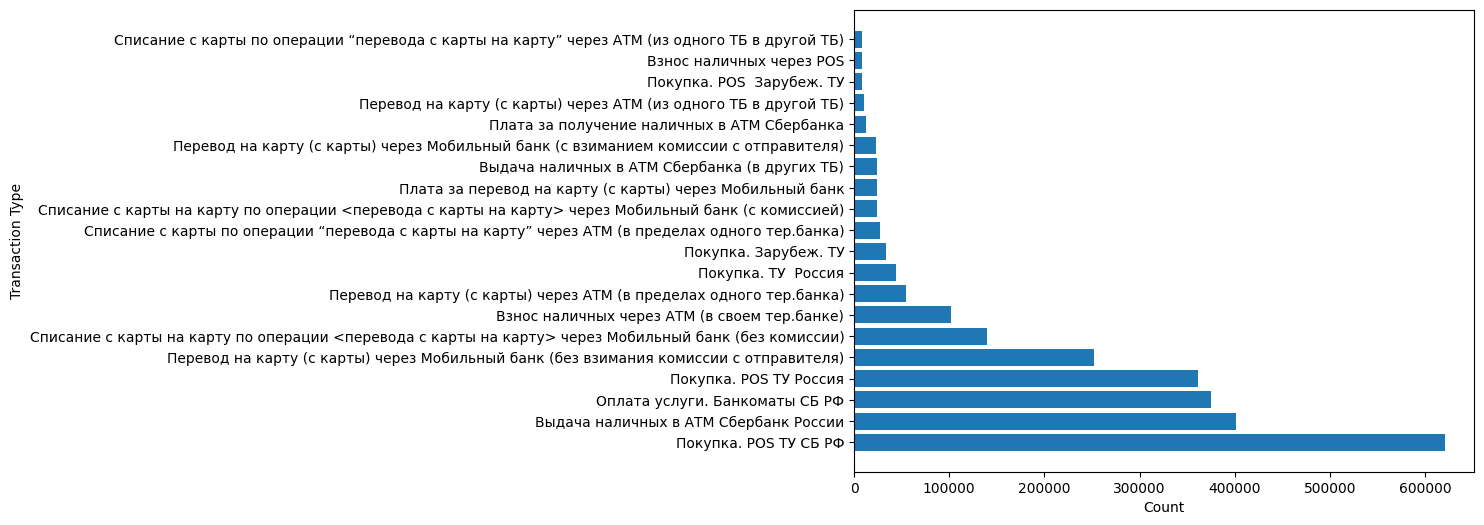

In [4]:
def plot_top_counts(series, top_n=20, xlabel="Count", ylabel=""):
    counts = series.value_counts()
    top_items = counts.nlargest(top_n)
    plt.figure(figsize=(8,6))
    plt.barh(top_items.index, top_items.values)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

plot_top_counts(
    train_df.tr_type_desc.apply(str),
    ylabel="Transaction Type"
)

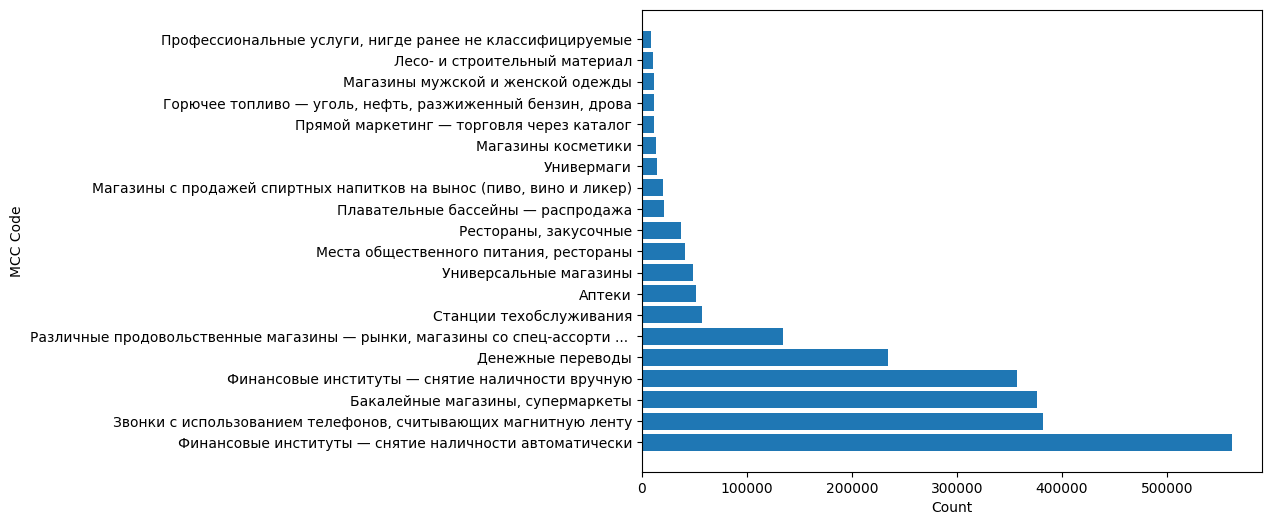

In [5]:
plot_top_counts(
    series=train_df.mcc_code_desc.apply(lambda x: x[:70] if len(x) < 70 else x[:70] + " ... "),
    ylabel="MCC Code"
)

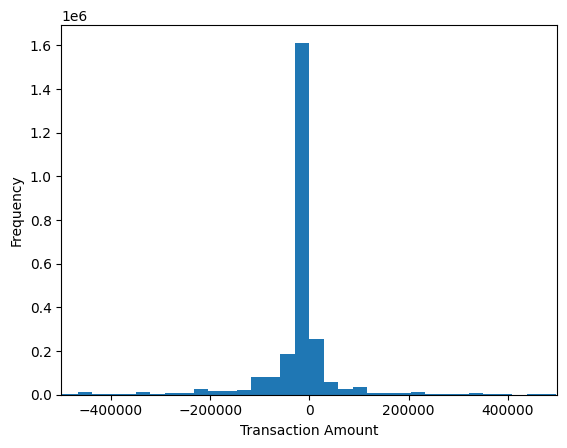

In [6]:
train_df.amount.plot.hist(bins=10000)
plt.xlim([-5e5, 5e5])
plt.xlabel("Transaction Amount")
plt.show()

# Feature Engineering

In [7]:
def baseline_aggregation(df):
    tx_stats = df.groupby('customer_id').agg({
        'amount': ['count', 'sum'],
        'mcc_code': pd.Series.nunique,
        'tr_type': pd.Series.nunique,
    })
    tx_stats.columns = [f'base_{k}_{stat}' for k, stat in tx_stats.columns]
    tx_stats.reset_index(inplace=True)

    target = df[['customer_id', 'gender']].drop_duplicates()
    features = tx_stats.merge(target, on='customer_id', how='left')

    X = features.drop(columns=['customer_id', 'gender'])
    y = features['gender']

    return X, y

X_train, y_train = baseline_aggregation(dataset["train"])
X_test, y_test = baseline_aggregation(dataset["test"])
X_val, y_val = baseline_aggregation(dataset["val"])

assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]

## Train & Eval

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, average_precision_score,
    precision_score, recall_score
)

def eval(y_val, y_pred, y_pred_proba):
    auc = roc_auc_score(y_val, y_pred_proba)
    acc = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    return {
        "auc_score": auc,
        "accuracy_score": acc,
        "precision_score": precision,
        "recall_score": recall
    }

def fit_predict_rf(X_train, y_train, X_val, y_val, X_test):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train) 

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    return y_pred_proba, y_pred

y_pred_proba, y_pred = fit_predict_rf(X_train, y_train, X_val, y_val, X_test)
metrics = eval(y_test, y_pred, y_pred_proba)
metrics

{'auc_score': 0.5737087280045527,
 'accuracy_score': 0.5577380952380953,
 'avg_precision_score': 0.5214870020263379,
 'precision_score': 0.5238095238095238,
 'recall_score': 0.4269081500646831}

## Your solution

In [ ]:
def generate_features(df):
    """
    Custom feature generation function.
    Returns:
        X: pd.DataFrame of features
        y: pd.Series target
    """
    raise NotImplementedError


def fit_predict_proba(X_train, y_train, X_val, y_val, X_test):
    """
    Fit a classifier on the training data and predict probabilities and binary labels 
    for the test set.

    Parameters
    ----------
    X_train : pd.DataFrame or np.ndarray
        Feature matrix for training.
    y_train : pd.Series or np.ndarray
        Target vector for training.
    X_val : pd.DataFrame or np.ndarray
        Feature matrix for validation (can be used for hyperparameter tuning or early stopping).
    y_val : pd.Series or np.ndarray
        Target vector for validation.
    X_test : pd.DataFrame or np.ndarray
        Feature matrix for testing/prediction.

    Returns
    -------
    y_pred_proba : np.ndarray
        Predicted probabilities of the positive class for X_test.
    y_pred : np.ndarray
        Predicted binary labels for X_test (thresholded at 0.5 by default).
    """
    raise NotImplementedError

In [ ]:
# Feature engineering
X_train, y_train = generate_features(dataset["train"])
X_test, y_test = generate_features(dataset["test"])
X_val, y_val = generate_features(dataset["val"])

assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]

# Model training and prediction
y_pred_proba, y_pred = fit_predict_proba(X_train, y_train, X_val, y_val, X_test)

# Evaluation
metrics = eval(y_test, y_pred, y_pred_proba)
metrics